# Anomalies investigation

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

from sentinel.ml_logic.data import PROCESSED_DIR, find_anomaly_segments
from sentinel.ml_logic.viz  import plot_segment_zoom

sns.set_theme(style="whitegrid")

# format large row indices with thousands separators on every axis
ROW_FMT = FuncFormatter(lambda x, _: f"{int(x):,}")

## 2. Load `test_intern_raw` + labels

In [2]:
X_test = np.load(PROCESSED_DIR / "test_intern_raw.npy")
y_test = np.load(PROCESSED_DIR / "y_test_intern.npy")

with open(PROCESSED_DIR / "preprocessing_config.json") as f:
    features = json.load(f)["target_channels"]

df_test = pd.DataFrame(X_test, columns=features)
df_test["is_anomaly"] = y_test

print(f"X_test: {X_test.shape}   y_test: {y_test.shape}")
print(f"anomaly rows: {int(y_test.sum()):,} ({y_test.mean()*100:.2f}%)")

X_test: (2186220, 58)   y_test: (2186220,)
anomaly rows: 214,961 (9.83%)


## 3. Find contiguous anomaly segments

In [3]:
segments = find_anomaly_segments(y_test)
seg_df   = pd.DataFrame(segments)
seg_df["center"] = (seg_df["start"] + seg_df["end"]) // 2

print(f"total segments          : {len(seg_df)}")
print(f"total anomaly rows      : {seg_df['length'].sum():,}")
print(f"avg / median / max len  : "
      f"{seg_df['length'].mean():.0f}  /  "
      f"{seg_df['length'].median():.0f}  /  "
      f"{seg_df['length'].max():,}")

seg_df.sort_values("length", ascending=False).head(5)

total segments          : 27
total anomaly rows      : 214,961
avg / median / max len  : 7962  /  67  /  68,341


,start,end,length,center
15,1655773,1724113,68341,1689943
16,1776634,1829227,52594,1802930
3,576150,607979,31830,592064
19,1866779,1886701,19923,1876740
7,1061595,1074539,12945,1068067


## 4. Gantt overview — every segment along the full timeline

Each horizontal bar is one anomaly event; colour shows its length. Clusters in the x-axis are exactly the "dense" regions the colleague is after.

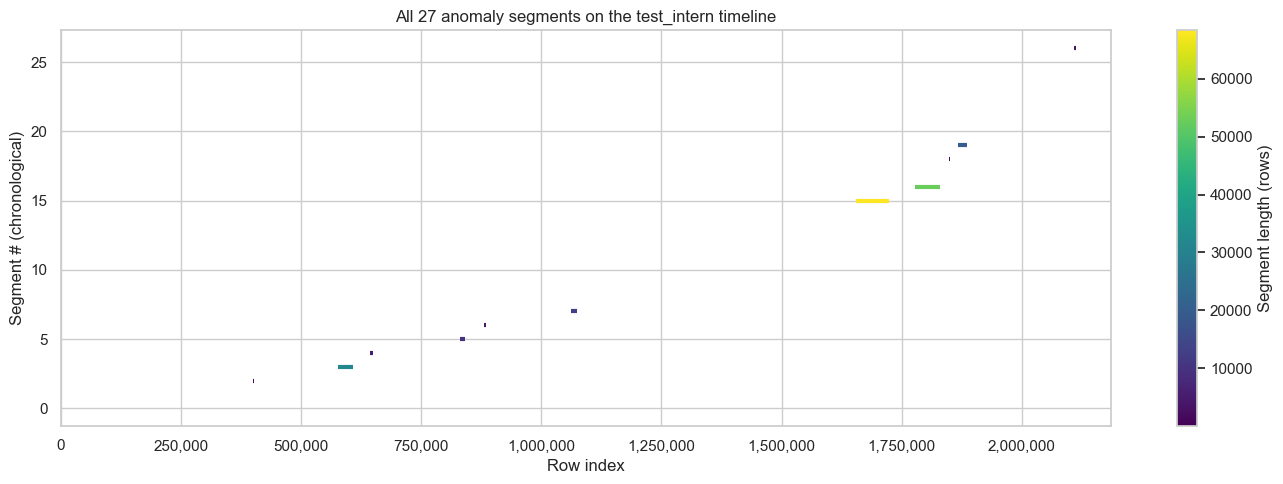

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))

norm = plt.Normalize(vmin=seg_df["length"].min(),
                     vmax=seg_df["length"].max())
cmap = plt.get_cmap("viridis")

# one horizontal bar per segment, y-position = index in seg_df order (row order)
for i, s in seg_df.iterrows():
    ax.hlines(y=i, xmin=s["start"], xmax=s["end"],
              colors=cmap(norm(s["length"])), linewidth=3)

ax.set_xlim(0, len(y_test))
ax.xaxis.set_major_formatter(ROW_FMT)   # proper row-index labels
ax.set_xlabel("Row index")
ax.set_ylabel("Segment # (chronological)")
ax.set_title(f"All {len(seg_df)} anomaly segments on the test_intern timeline")

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Segment length (rows)")

fig.tight_layout()
plt.show()

## 5. Segment density — which row-index windows contain the most events?

Bin the timeline into fixed-size row windows and count how many anomaly segments have their centre in each bin. The tallest bars are our candidate "cool visualisation" regions.

In [5]:
BIN = 200_000   # width of one density bucket

bin_edges = np.arange(0, len(y_test) + BIN, BIN)
counts, _ = np.histogram(seg_df["center"], bins=bin_edges)

density = pd.DataFrame({
    "bin_start": bin_edges[:-1],
    "bin_end"  : bin_edges[1:],
    "n_events" : counts,
})
density["label"] = density.apply(
    lambda r: f"{int(r['bin_start']):,}–{int(r['bin_end']):,}", axis=1
)
density_hot = density.sort_values("n_events", ascending=False).head(5)
print("Top-5 anomaly-dense bins:")
print(density_hot.to_string(index=False))

Top-5 anomaly-dense bins:
 bin_start  bin_end  n_events               label
   2000000  2200000         6 2,000,000–2,200,000
   1000000  1200000         5 1,000,000–1,200,000
   1800000  2000000         5 1,800,000–2,000,000
         0   200000         2           0–200,000
    400000   600000         2     400,000–600,000


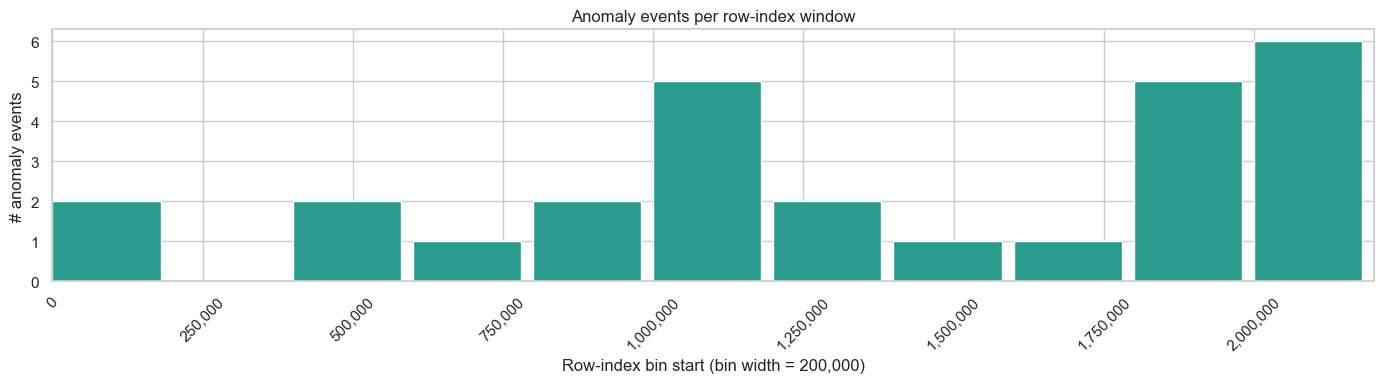

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))

# matplotlib bar (numeric x) instead of sns.barplot so the axis
# actually shows the real row indices, not the categorical 0..N positions.
ax.bar(
    density["bin_start"], density["n_events"],
    width=BIN * 0.9, align="edge", color="#2a9d8f",
)
ax.set_xlim(0, density["bin_end"].max())
ax.xaxis.set_major_formatter(ROW_FMT)
ax.tick_params(axis="x", rotation=45)
ax.set_xlabel(f"Row-index bin start (bin width = {BIN:,})")
ax.set_ylabel("# anomaly events")
ax.set_title("Anomaly events per row-index window")
fig.tight_layout()
plt.show()

## 6. Zoom into the top-2 densest regions

For each dense bin we plot four channels across the bin's full row range (no extra context — the bin already is the context). Every anomaly segment inside is shaded.

rank 1: rows 2,000,000–2,200,000   events=6   rows flagged inside bin: 5,039


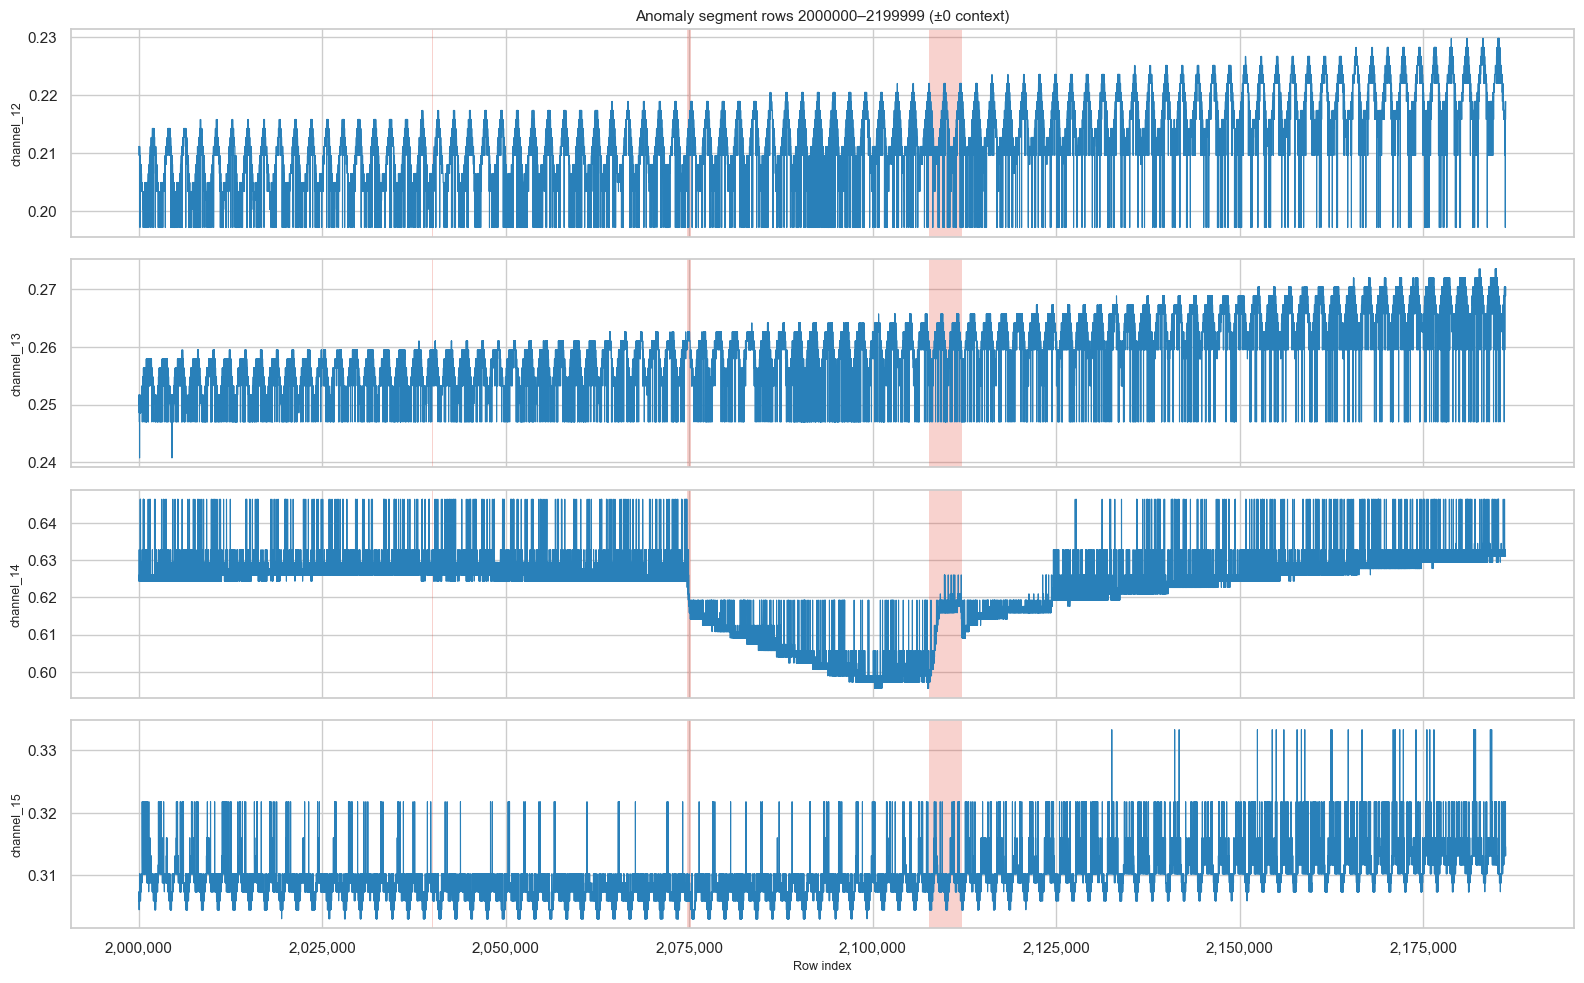

rank 2: rows 1,000,000–1,200,000   events=5   rows flagged inside bin: 13,057


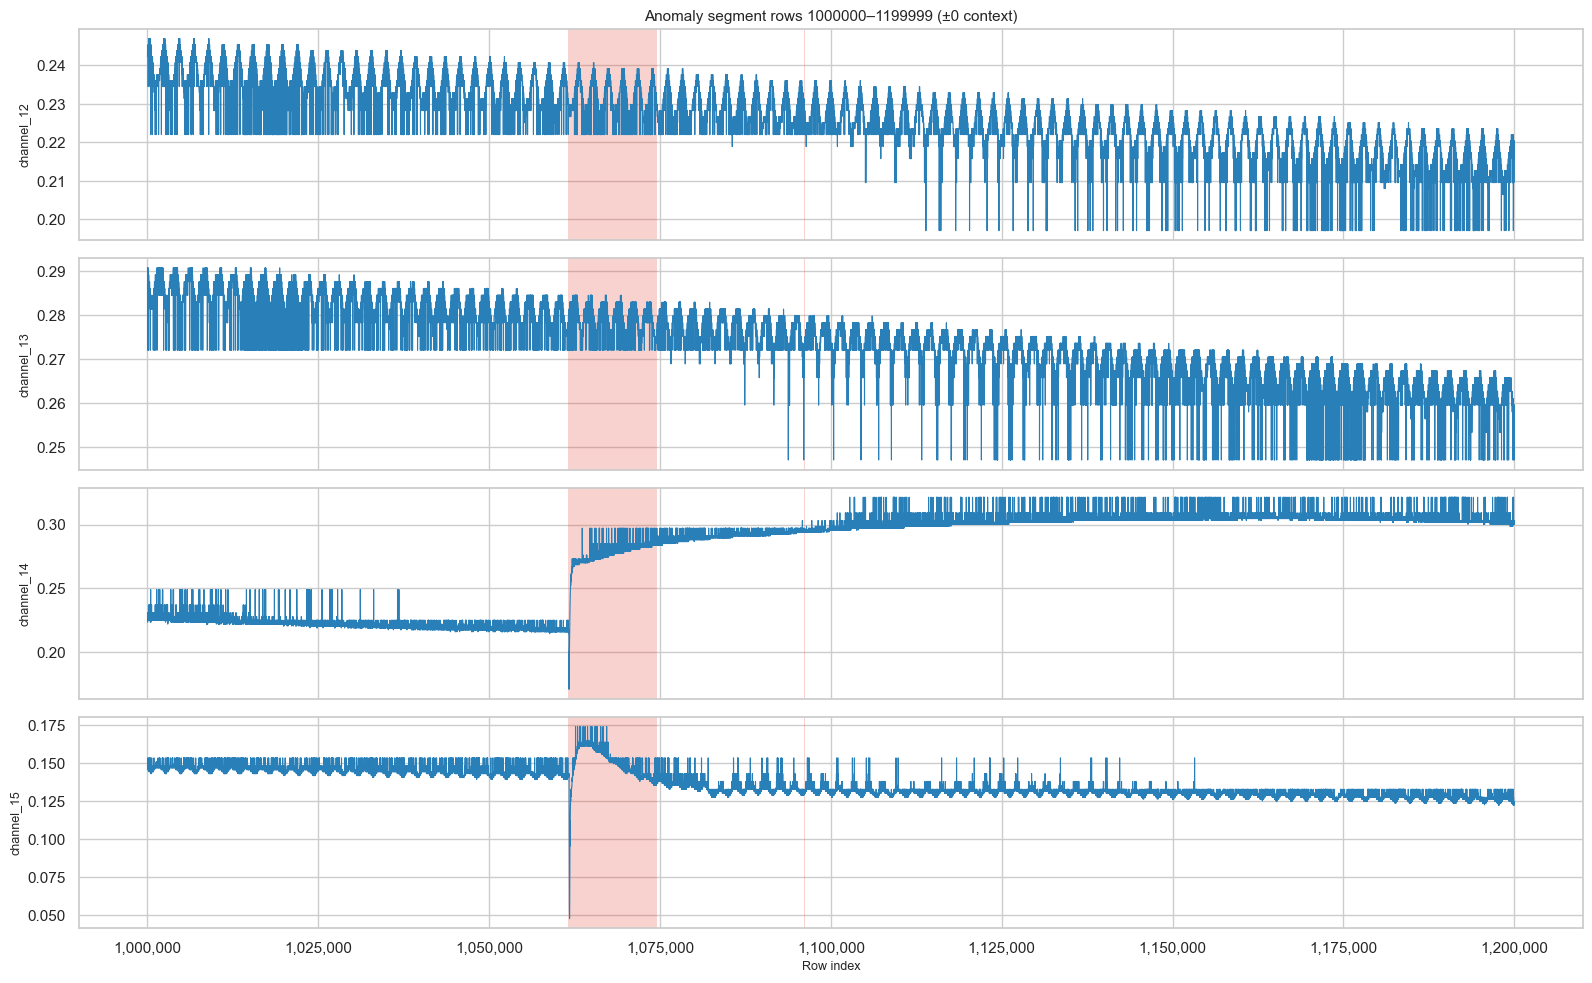

In [7]:
TOP_N         = 2
PICK_CHANNELS = features[:4]   # first four target channels

for rank in range(TOP_N):
    bin_row = density_hot.iloc[rank]
    lo, hi, n_ev = int(bin_row["bin_start"]), int(bin_row["bin_end"]), int(bin_row["n_events"])

    # segments whose centre falls in this bin
    in_bin = seg_df[(seg_df["center"] >= lo) & (seg_df["center"] < hi)]
    print(f"rank {rank+1}: rows {lo:,}–{hi:,}   events={n_ev}   "
          f"rows flagged inside bin: {int(y_test[lo:hi].sum()):,}")

    fig = plot_segment_zoom(
        df        = df_test,
        channels  = PICK_CHANNELS,
        seg_start = lo,
        seg_end   = hi - 1,
        context   = 0,     # show exactly the bin range
    )
    # proper row-index labels on every channel panel
    for ax in fig.axes:
        ax.xaxis.set_major_formatter(ROW_FMT)
    plt.show()